In [170]:
import pandas as pd
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

First determine how many unique MOAs there are, and for each MOA, how many unique drugs there are. MOA data are from the drug repurposing hub and signatures are from the L1000 FWD. 

In [171]:
moa_data = pd.read_csv("./data/l1000/repo-drug-annotation-20200324.txt", sep="\t", skiprows=9)
moa_data.head()

,pert_iname,clinical_phase,moa,target,disease_area,indication
0,10058-F4,Preclinical,c-Myc inhibitor,NaN,NaN,NaN
1,10-deacetylbaccatin,Preclinical,antitumor agent,NaN,NaN,NaN
2,10-DEBC,Preclinical,AKT inhibitor,PIM1,NaN,NaN
3,10-hydroxycamptothecin,Preclinical,topoisomerase inhibitor,TOP1,NaN,NaN
4,"1,12-Besm",Phase 2,polyamine biosynthesis inhibitor,NaN,NaN,NaN


In [172]:
signature_metadata = pd.read_csv("./data/l1000/CD_signature_metadata.csv")
signature_metadata.head()

,sig_id,SCS_centered_by_batch,batch,cell_id,mean_cosine_dist_centered_by_batch,pert_desc,pert_dose,pert_id,pert_time
0,AML001_CD34_6H:BRD-K43389675:10,0.0,AML001_CD34_6H,CD34,0.853471,DAUNORUBICIN,10.00000,BRD-K43389675,6.0
1,AML001_PC3_6H:BRD-A19037878:0.37037,0.0,AML001_PC3_6H,PC3,0.505995,TRICHOSTATIN_A,0.37037,BRD-A19037878,6.0
2,AML001_PC3_6H:BRD-A19037878:1.11111,0.0,AML001_PC3_6H,PC3,0.676204,TRICHOSTATIN_A,1.11111,BRD-A19037878,6.0
3,AML001_PC3_6H:BRD-A19037878:10,0.0,AML001_PC3_6H,PC3,0.747633,TRICHOSTATIN_A,10.00000,BRD-A19037878,6.0
4,AML001_PC3_6H:BRD-A19037878:3.33333,0.0,AML001_PC3_6H,PC3,0.659851,TRICHOSTATIN_A,3.33333,BRD-A19037878,6.0


Note: This is the num

In [173]:
drug_to_moa = signature_metadata.merge(moa_data, left_on="pert_desc", right_on="pert_iname", how='left')
drug_to_moa = drug_to_moa[['pert_id', 'pert_iname','moa']].drop_duplicates().set_index('pert_id')
drug_to_moa = drug_to_moa.fillna("unknown")
print("Number of unique drugs per moa:"), display(drug_to_moa['moa'].value_counts())

Number of unique drugs per moa:


moa
unknown                                               4751
dopamine receptor antagonist                            13
glucocorticoid receptor agonist                         13
adrenergic receptor antagonist                          12
cyclooxygenase inhibitor                                12
                                                      ... 
GABA uptake inhibitor                                    1
potassium channel blocker | sodium channel blocker       1
insulin sensitizer | PPAR receptor agonist               1
glycine receptor antagonist                              1
cytochrome P450 inhibitor | SIRT activator               1
Name: count, Length: 245, dtype: int64

(None, None)

In [174]:
drug_to_moa[drug_to_moa['moa'].str.contains('egfr inhibitor', case=False)]

,pert_iname,moa
pert_id,,
BRD-K23984367,sorafenib,FLT3 inhibitor | KIT inhibitor | PDGFR tyrosin...
BRD-K47105409,AG-490,EGFR inhibitor | JAK inhibitor
BRD-K25340465,OSI-930,KIT inhibitor | VEGFR inhibitor


In [175]:
drug_to_moa.shape, len(drug_to_moa['moa'].value_counts())

((5249, 2), 245)

Upload gmt as dictionary

In [176]:
up_gmt = {}
dn_gmt = {}
with open("./data/l1000/CD_signatures_binary_42809.gmt",'r') as f:
    for line in f:
        tokens = line.strip().split("\t")
        term = tokens[0]
        direction = tokens[1]
        gset = tokens[2:]
        if direction == 'up':
            up_gmt[term] = gset
        else:
            dn_gmt[term] = gset

gmt_terms = list(up_gmt.keys()) + list(dn_gmt.keys())
len(gmt_terms), gmt_terms[:5]

(85618,
 ['CPC014_HCC515_6H:BRD-K50168500-001-01-2:10',
  'CPC009_MCF7_6H:BRD-K49094915-019-01-5:10',
  'CPC006_NCIH1694_6H:BRD-K17349619-003-01-4:10',
  'CPC015_NPC_24H:BRD-A72596465-001-01-3:10',
  'CPC011_HA1E_6H:BRD-A19037878:10'])

Target moas used in the L1000 fwd

In [177]:
fwd_target_moas = [
    "protein synthesis inhibitor", 
    'dopamine receptor antagonist', 
    "NFkB pathway inhibitor", 
    "topoisomerase inhibitor", 
    "HDAC inhibitor",
    "ATPase inhibitor",
    "HMGCR inhibitor",
    "PI3K inhibitor",
    "tubulin polymerization inhibitor",
    "HSP inhibitor",
    "mTOR inhibitor",
    "adrenergic receptor antagonist",
    "MEK inhibitor",
    "EGFR inhibitor",
    "other",
    "unknown",
    "retinoid receptor agonist",
    "glucocorticoid receptor agonist",
    "CDK inhibitor",
    "adrenergic receptor agonist"
    ]

In [178]:
drug_to_moa['moa']

pert_id
BRD-K43389675                                              unknown
BRD-A19037878                                              unknown
BRD-A19500257                                              unknown
BRD-A45664787                                              unknown
BRD-A75409952                                              unknown
                                       ...                        
BRD-K92870997                                              unknown
BRD-A58955223    anticancer agent | aryl hydrocarbon receptor a...
BRD-A25004090                                              unknown
BRD-K32107296                                 DNA alkylating agent
BRD-K80738081           cytochrome P450 inhibitor | SIRT activator
Name: moa, Length: 5249, dtype: object

Top 30 most common MOAs

In [179]:
top30_target_moas = drug_to_moa['moa'].value_counts().index.to_list()[:31] # add 1 to include top 30 + unknown
top30_target_moas

['unknown',
 'dopamine receptor antagonist',
 'glucocorticoid receptor agonist',
 'adrenergic receptor antagonist',
 'cyclooxygenase inhibitor',
 'histamine receptor antagonist',
 'calcium channel blocker',
 'tubulin polymerization inhibitor',
 'phosphodiesterase inhibitor',
 'bacterial cell wall synthesis inhibitor',
 'adrenergic receptor agonist',
 'acetylcholine receptor antagonist',
 'PARP inhibitor',
 'selective serotonin reuptake inhibitor (SSRI)',
 'PI3K inhibitor',
 'HIV protease inhibitor',
 'adenosine receptor agonist',
 'serotonin receptor antagonist',
 'sodium channel blocker',
 'mTOR inhibitor',
 'HDAC inhibitor',
 'HMGCR inhibitor',
 'bacterial DNA gyrase inhibitor',
 'AKT inhibitor',
 'ATPase inhibitor',
 'DNA synthesis inhibitor',
 'estrogen receptor agonist',
 'potassium channel blocker',
 'Aurora kinase inhibitor',
 'bacterial 50S ribosomal subunit inhibitor',
 'potassium channel activator']

In [180]:
# first map target_moas to drugs
def map_name(x):
    multiple_moas = x.split("|")
    for moa in multiple_moas:
        for target_moa in top30_target_moas:
            if target_moa.lower() in moa.strip().lower():
                return target_moa
    return "other"
drug_to_moa['moa'] = drug_to_moa['moa'].map(lambda x: map_name(x))
drug_to_moa['moa'].value_counts()

moa
unknown                                          4751
other                                             268
dopamine receptor antagonist                       16
cyclooxygenase inhibitor                           16
adrenergic receptor antagonist                     16
glucocorticoid receptor agonist                    15
calcium channel blocker                            11
histamine receptor antagonist                      11
tubulin polymerization inhibitor                   10
phosphodiesterase inhibitor                        10
mTOR inhibitor                                      9
serotonin receptor antagonist                       9
bacterial cell wall synthesis inhibitor             9
estrogen receptor agonist                           7
adrenergic receptor agonist                         7
PARP inhibitor                                      6
acetylcholine receptor antagonist                   6
selective serotonin reuptake inhibitor (SSRI)       6
HDAC inhibitor          

In [181]:
consensus_cutoff = 0.17

In [182]:
UP_consensus_moa_gmt = {}
DOWN_consensus_moa_gmt = {}
up_drugs = {moa:set() for moa in top30_target_moas} # set of all moa_drugs included in the up gmt
dn_drugs = {moa:set() for moa in top30_target_moas} # set of all moa_drugs included in the down gmt
summary = []
up_summary_df = pd.DataFrame(index=top30_target_moas, columns=['Up Signatures', 'Up genes', 'Down Signatures' 'Down genes'])

# drug_to_up_sigs = dict(list)
# for term in up_gmt.items():
#     drug = "-".join(term.split(':')[1].split("-")[:2])
#     drug_to_up_sigs[drug].append(term)

# drug_to_dn_sigs = dict(list)
# for term in DOWN_consensus_moa_gmt:
#     drug = term.split('_')[0]
#     drug_to_dn_sigs[drug].append(term)

drug_groups = drug_to_moa.groupby(by='moa')
# for each of the target moas
for moa in top30_target_moas:
    moa_drugs = drug_groups.get_group(moa).index.to_list() # get the moa_drugs for that moa

    #--------------UP GENES----------------#
    up_sigs = [] # TODO: this is super inefficient - move out of loop (see above)
    for drug in moa_drugs:
        for term, _ in up_gmt.items():
            if drug in term:
                up_sigs.append(term)
                up_drugs[moa].add(drug)

    up_genes= []

    for sig in up_sigs: # find up_genes that are in at least 50% of up up_sigs for that drug
        up_genes.extend(up_gmt[sig])
    
    gene_counts = Counter(up_genes)
    up_consensus_genes = [g for g,count in gene_counts.items() if count >= len(up_sigs)*consensus_cutoff]
    UP_consensus_moa_gmt[moa] = up_consensus_genes # save moa signature 

    #--------------DOWN GENES----------------#
    dn_sigs = []
    for drug in moa_drugs:
        for term, _ in dn_gmt.items():
            if drug in term:
                dn_sigs.append(term)
                dn_drugs[moa].add(drug)
                
    dn_genes = []
    for sig in dn_sigs:
        dn_genes.extend(dn_gmt[sig])
    gene_counts = Counter(dn_genes)
    dn_consensus_genes = [g for g,count in gene_counts.items() if count >= len(dn_sigs)*consensus_cutoff]
    DOWN_consensus_moa_gmt[moa] = dn_consensus_genes # save moa signature 
    summary.append((moa, len(up_sigs), len(up_consensus_genes), len(dn_consensus_genes)))

summary_df = pd.DataFrame(summary, columns=['moa', 'Signatures', 'Up genes', 'Down genes']).set_index('moa')

In [183]:
summary_df.to_clipboard()
summary_df

,Signatures,Up genes,Down genes
moa,,,
unknown,41455,66,57
dopamine receptor antagonist,345,146,88
glucocorticoid receptor agonist,136,153,177
adrenergic receptor antagonist,77,104,116
cyclooxygenase inhibitor,124,94,96
histamine receptor antagonist,54,126,116
calcium channel blocker,62,159,97
tubulin polymerization inhibitor,193,231,189
phosphodiesterase inhibitor,65,113,129


In [184]:
del UP_consensus_moa_gmt['unknown']
del DOWN_consensus_moa_gmt['unknown']

matrix of overlapping genes

In [185]:
up_matrix = pd.DataFrame(index=UP_consensus_moa_gmt.keys(), columns=UP_consensus_moa_gmt.keys(), data=0)

# fill in each entry i,j with the length of intersection of the gene sets i,j by row
for col in up_matrix.columns:
    for row in up_matrix.index:
        up_matrix.loc[row,col] = len(set(UP_consensus_moa_gmt[row]) & set(UP_consensus_moa_gmt[col]))
# for each row
up_matrix.head()

,dopamine receptor antagonist,glucocorticoid receptor agonist,adrenergic receptor antagonist,cyclooxygenase inhibitor,histamine receptor antagonist,calcium channel blocker,tubulin polymerization inhibitor,phosphodiesterase inhibitor,bacterial cell wall synthesis inhibitor,adrenergic receptor agonist,...,HMGCR inhibitor,bacterial DNA gyrase inhibitor,AKT inhibitor,ATPase inhibitor,DNA synthesis inhibitor,estrogen receptor agonist,potassium channel blocker,Aurora kinase inhibitor,bacterial 50S ribosomal subunit inhibitor,potassium channel activator
dopamine receptor antagonist,146,46,52,34,53,53,49,41,48,59,...,69,40,83,39,46,37,93,49,44,55
glucocorticoid receptor agonist,46,153,42,41,40,47,42,36,57,54,...,52,48,50,56,44,40,54,34,59,52
adrenergic receptor antagonist,52,42,104,34,43,41,34,40,53,49,...,54,42,52,42,40,32,59,34,48,50
cyclooxygenase inhibitor,34,41,34,94,39,44,30,33,39,53,...,39,44,31,33,44,36,41,37,42,53
histamine receptor antagonist,53,40,43,39,126,44,52,49,49,54,...,51,53,55,42,48,41,51,47,60,58


<Figure size 1000x1000 with 0 Axes>

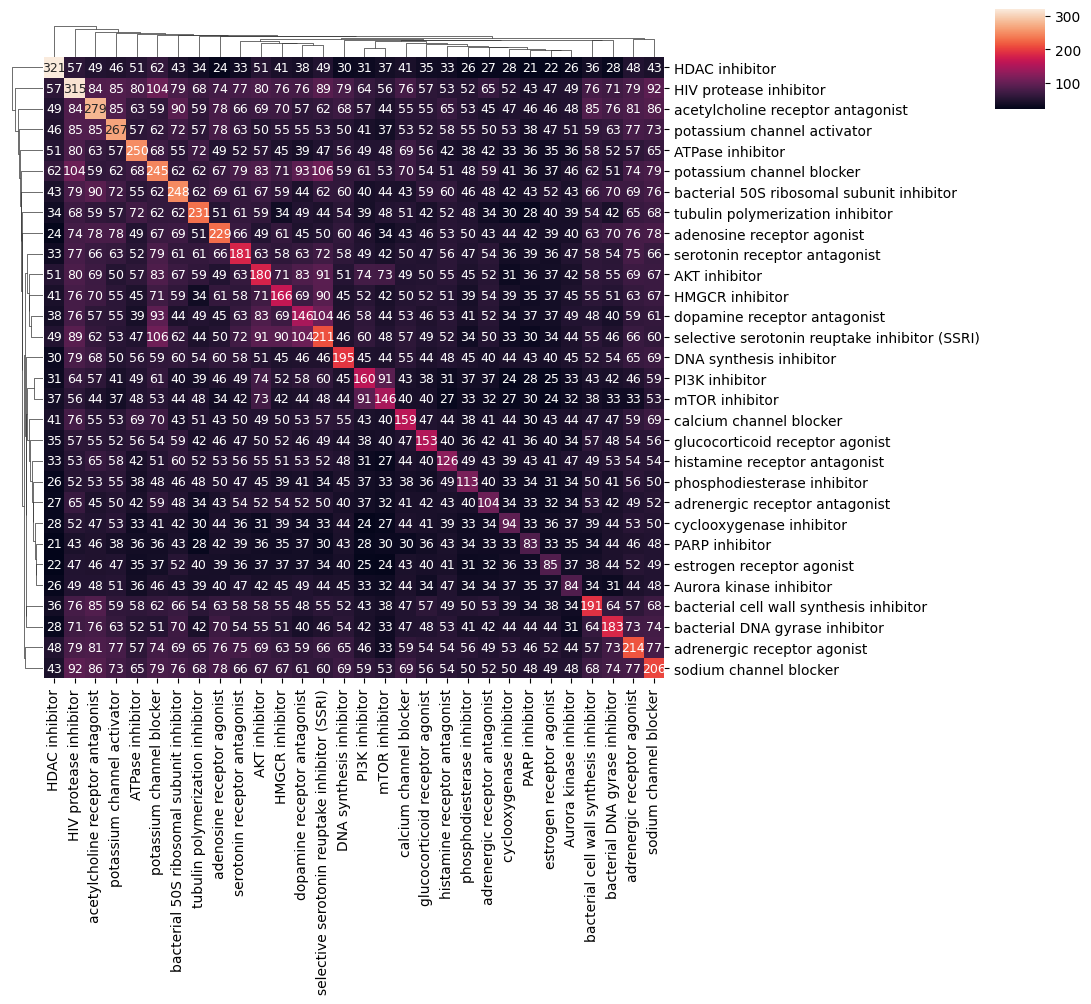

In [186]:
plt.figure(figsize=(10,10))
sns.clustermap(up_matrix, annot=True, annot_kws={"fontsize": 9}, fmt='d', dendrogram_ratio=(0.05, 0.05), cbar_pos=(1,0.9,0.05,0.1))

In [187]:
down_matrix = pd.DataFrame(index=DOWN_consensus_moa_gmt.keys(), columns=DOWN_consensus_moa_gmt.keys(), data=0)

# fill in each entry i,j with the length of intersection of the gene sets i,j by row
for col in down_matrix.columns:
    for row in down_matrix.index:
        down_matrix.loc[row,col] = len(set(DOWN_consensus_moa_gmt[row]) & set(DOWN_consensus_moa_gmt[col]))
# for each row
down_matrix.head()

,dopamine receptor antagonist,glucocorticoid receptor agonist,adrenergic receptor antagonist,cyclooxygenase inhibitor,histamine receptor antagonist,calcium channel blocker,tubulin polymerization inhibitor,phosphodiesterase inhibitor,bacterial cell wall synthesis inhibitor,adrenergic receptor agonist,...,HMGCR inhibitor,bacterial DNA gyrase inhibitor,AKT inhibitor,ATPase inhibitor,DNA synthesis inhibitor,estrogen receptor agonist,potassium channel blocker,Aurora kinase inhibitor,bacterial 50S ribosomal subunit inhibitor,potassium channel activator
dopamine receptor antagonist,88,34,37,22,51,27,39,43,36,35,...,43,44,42,43,36,44,55,40,40,35
glucocorticoid receptor agonist,34,177,48,39,46,33,51,53,38,44,...,54,74,33,52,43,46,49,39,83,61
adrenergic receptor antagonist,37,48,116,37,46,37,46,59,36,44,...,51,66,36,42,44,47,52,45,64,51
cyclooxygenase inhibitor,22,39,37,96,34,25,30,38,28,28,...,29,47,21,28,34,36,27,31,48,46
histamine receptor antagonist,51,46,46,34,116,31,58,51,38,44,...,46,63,42,45,45,52,52,50,60,48


<Figure size 1000x1000 with 0 Axes>

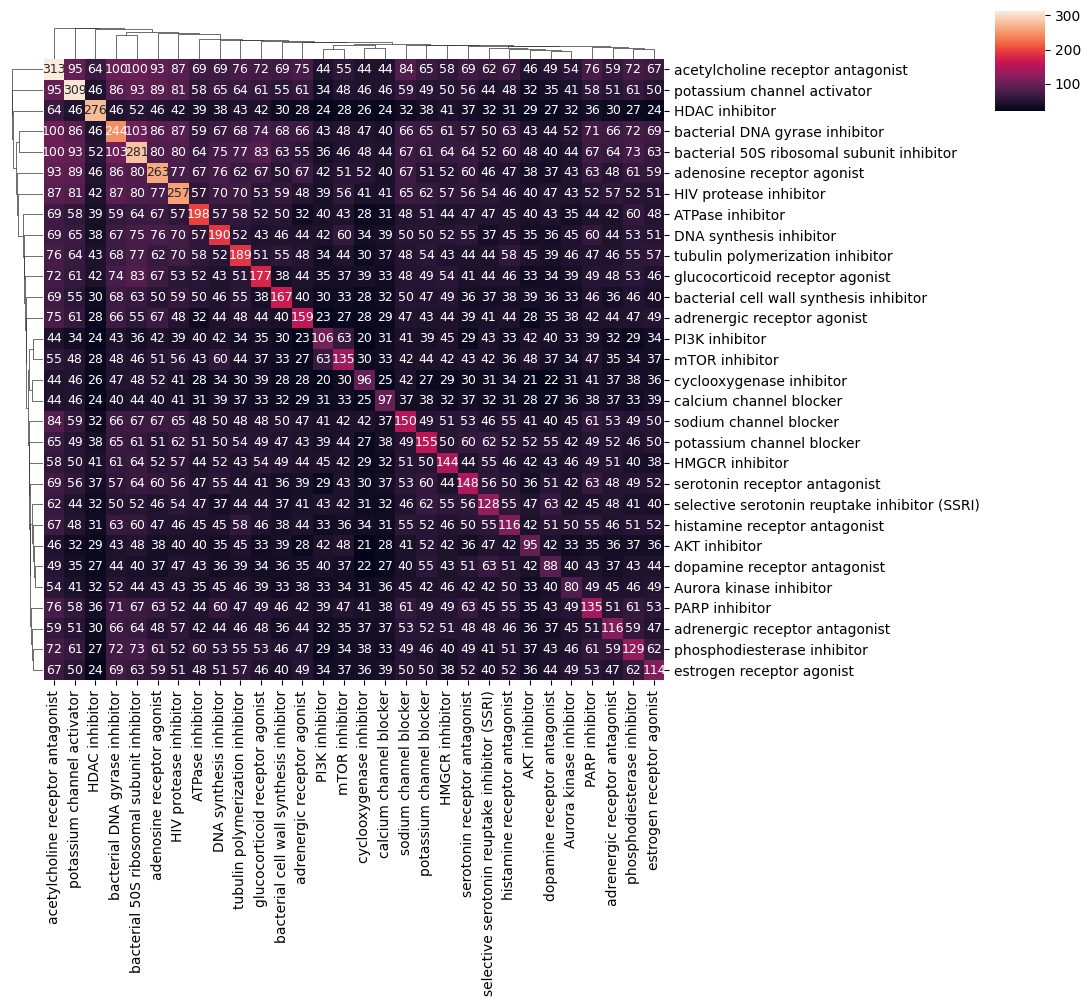

In [188]:
plt.figure(figsize=(10,10))
sns.clustermap(down_matrix, annot=True, annot_kws={"fontsize": 9}, fmt='d', dendrogram_ratio=(0.05, 0.05), cbar_pos=(1,0.9,0.05,0.1))

In [189]:
updown_matrix = pd.DataFrame(index=UP_consensus_moa_gmt.keys(), columns=DOWN_consensus_moa_gmt.keys(), data=0)

# fill in each entry i,j with the length of intersection of the gene sets i,j by row
for col in updown_matrix.columns:
    for row in updown_matrix.index:
        updown_matrix.loc[row,col] = len(set(UP_consensus_moa_gmt[row]) & set(DOWN_consensus_moa_gmt[col]))
# for each row
updown_matrix.head()

,dopamine receptor antagonist,glucocorticoid receptor agonist,adrenergic receptor antagonist,cyclooxygenase inhibitor,histamine receptor antagonist,calcium channel blocker,tubulin polymerization inhibitor,phosphodiesterase inhibitor,bacterial cell wall synthesis inhibitor,adrenergic receptor agonist,...,HMGCR inhibitor,bacterial DNA gyrase inhibitor,AKT inhibitor,ATPase inhibitor,DNA synthesis inhibitor,estrogen receptor agonist,potassium channel blocker,Aurora kinase inhibitor,bacterial 50S ribosomal subunit inhibitor,potassium channel activator
dopamine receptor antagonist,25,45,40,48,42,40,51,48,37,33,...,33,62,28,40,57,45,36,40,64,65
glucocorticoid receptor agonist,40,17,45,29,47,38,51,44,40,40,...,42,54,32,36,48,45,46,40,50,53
adrenergic receptor antagonist,35,36,40,41,45,29,45,42,29,36,...,26,45,26,33,38,47,34,39,51,50
cyclooxygenase inhibitor,45,34,40,20,45,38,51,43,38,32,...,42,47,41,44,40,41,45,44,47,42
histamine receptor antagonist,38,45,45,42,40,37,45,47,35,36,...,37,56,34,46,45,49,42,44,54,50


Text(1221.1527777777778, 0.5, 'down consensus gene sets')

<Figure size 1000x1000 with 0 Axes>

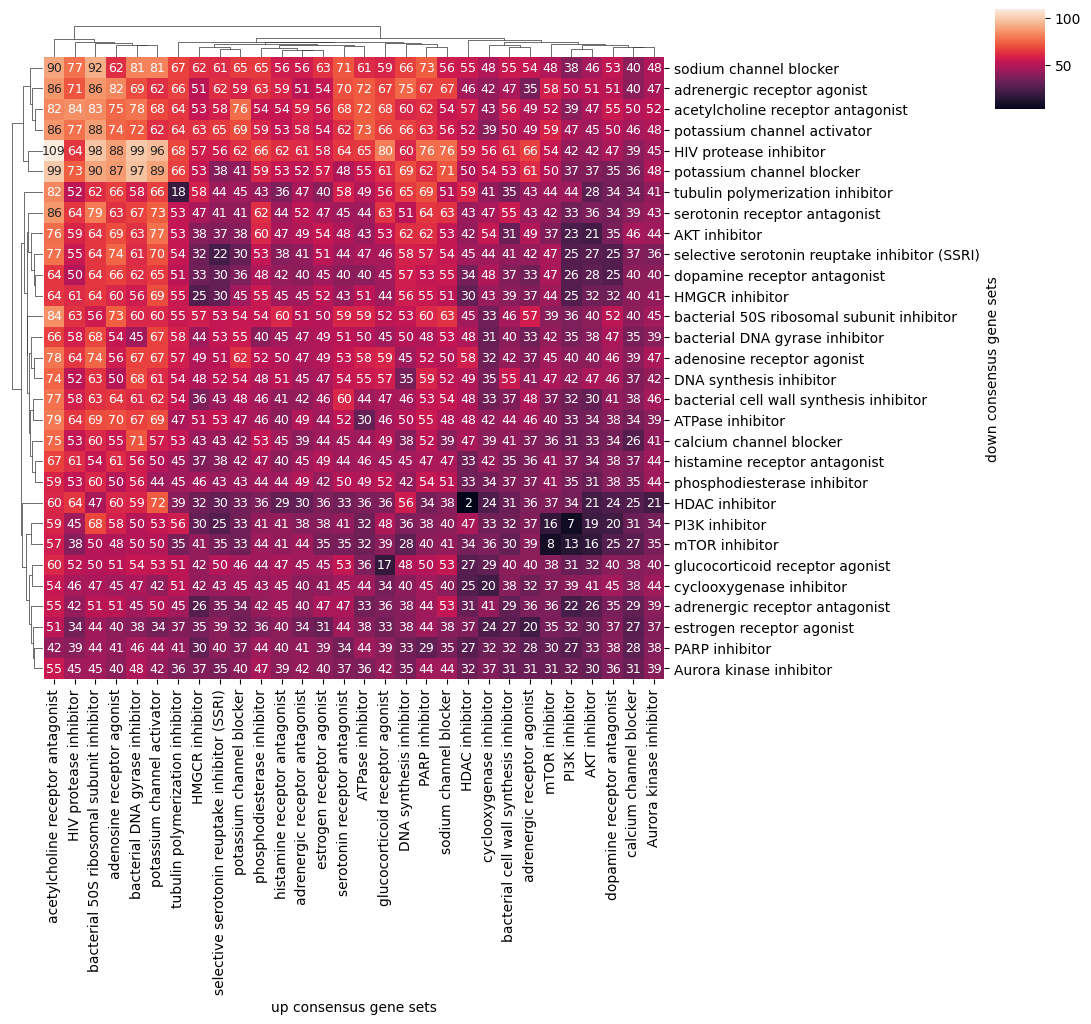

In [190]:
plt.figure(figsize=(10,10))
g = sns.clustermap(updown_matrix, annot=True, annot_kws={"fontsize": 9}, fmt='d', dendrogram_ratio=(0.05, 0.05), cbar_pos=(1,0.9,0.05,0.1))
g.ax_heatmap.set_xlabel('up consensus gene sets')
g.ax_heatmap.set_ylabel('down consensus gene sets')

In [191]:
with open("./data/out/up_consensus_top_30_moa.gmt", 'w') as f:
    for k,v in UP_consensus_moa_gmt.items():
        f.write(f'{k}\t\t{"\t".join(v)}\n')

In [192]:
with open("./data/out/down_consensus_top_30_moa.gmt", 'w') as f:
    for k,v in DOWN_consensus_moa_gmt.items():
        f.write(f'{k}\t\t{"\t".join(v)}\n')

## Build JSON

In [346]:
import json

moas_up = [
    {
        'direction': 'up',
        'moa': up_moa,
        'term':f'down:{up_moa}',
        # 'drug_list': list(up_drugs[moa])
    }
    for up_moa in UP_consensus_moa_gmt.keys()
]
    

moas_down = [
    {
        'direction':'down',
        'moa': dn_moa,
        'term':f'down:{dn_moa}',
        # 'drug_list': list(dn_drugs[moa])
    }
    for dn_moa in DOWN_consensus_moa_gmt.keys()
]

with open("../public/atlas2.json", 'r') as f:
    existing_atlas = json.load(f)

existing_atlas['moas'] = moas_up + moas_down

In [347]:
existing_atlas['moas']

[{'direction': 'up',
  'moa': 'dopamine receptor antagonist',
  'term': 'down:dopamine receptor antagonist'},
 {'direction': 'up',
  'moa': 'glucocorticoid receptor agonist',
  'term': 'down:glucocorticoid receptor agonist'},
 {'direction': 'up',
  'moa': 'adrenergic receptor antagonist',
  'term': 'down:adrenergic receptor antagonist'},
 {'direction': 'up',
  'moa': 'cyclooxygenase inhibitor',
  'term': 'down:cyclooxygenase inhibitor'},
 {'direction': 'up',
  'moa': 'histamine receptor antagonist',
  'term': 'down:histamine receptor antagonist'},
 {'direction': 'up',
  'moa': 'calcium channel blocker',
  'term': 'down:calcium channel blocker'},
 {'direction': 'up',
  'moa': 'tubulin polymerization inhibitor',
  'term': 'down:tubulin polymerization inhibitor'},
 {'direction': 'up',
  'moa': 'phosphodiesterase inhibitor',
  'term': 'down:phosphodiesterase inhibitor'},
 {'direction': 'up',
  'moa': 'bacterial cell wall synthesis inhibitor',
  'term': 'down:bacterial cell wall synthesis i

In [348]:
existing_atlas.keys()

dict_keys(['celltype', 'cancertype', 'moas'])

In [349]:
with open("../public/atlas1.json", "w") as f:
    json.dump(existing_atlas, f)

## Fisher's exact testing

In [196]:
# for each i,j entry in up_matrix
# build contingency table
# a = intersection size of set i, set j
# b = size(i) - size(a)
# c = size(j) - size(a)
# d = size(all genes) - size(j) - size(i) + size(a)
# make table of [[A, B],[C, D]]
# run fishers' exact
# save p value to matrix

In [197]:
from scipy.stats import fisher_exact
import numpy as np

In [198]:
all_up_genes = set([x for v in UP_consensus_moa_gmt.values() for x in v])
up_fishers_mat = pd.DataFrame(index=UP_consensus_moa_gmt.keys(), columns=UP_consensus_moa_gmt.keys(), data = -1)
for moa_i in up_matrix.index:
    for moa_j in up_matrix.columns:
        genes_i = set(UP_consensus_moa_gmt[moa_i])
        genes_j = set(UP_consensus_moa_gmt[moa_j])

        A = len(set(genes_i).intersection(set(genes_j)))
        B = len(genes_i) - A
        C = len(genes_j) - A
        D = len(set(all_up_genes) - (genes_i | genes_j))

        res = fisher_exact(np.array([[A, B], [C, D]]), alternative='greater')
        up_fishers_mat.loc[moa_i, moa_j] = res.pvalue

up_fishers_mat.head()

/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/185443427.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.548377675301976e-203' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  up_fishers_mat.loc[moa_i, moa_j] = res.pvalue
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/185443427.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.0935352598013138e-13' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  up_fishers_mat.loc[moa_i, moa_j] = res.pvalue
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/185443427.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.3154013557373916e-27' has dtype incompatible with int

,dopamine receptor antagonist,glucocorticoid receptor agonist,adrenergic receptor antagonist,cyclooxygenase inhibitor,histamine receptor antagonist,calcium channel blocker,tubulin polymerization inhibitor,phosphodiesterase inhibitor,bacterial cell wall synthesis inhibitor,adrenergic receptor agonist,...,HMGCR inhibitor,bacterial DNA gyrase inhibitor,AKT inhibitor,ATPase inhibitor,DNA synthesis inhibitor,estrogen receptor agonist,potassium channel blocker,Aurora kinase inhibitor,bacterial 50S ribosomal subunit inhibitor,potassium channel activator
dopamine receptor antagonist,1.548378e-203,2.093535e-13,1.315401e-27,1.752961e-12,1.610167e-23,6.833773e-18,3.676505e-08,4.046389e-15,9.495216e-11,1.481635e-15,...,2.194336e-31,4.606759e-07,6.819289e-44,2.437877e-03,2.900612e-09,1.017165e-16,1.395226e-41,4.027487e-30,4.750552e-05,1.055174e-08
glucocorticoid receptor agonist,2.093535e-13,4.934355e-210,1.094897e-16,9.152306e-18,9.556720e-12,1.591739e-12,1.380481e-04,1.223935e-10,1.236942e-15,2.548448e-11,...,3.813926e-15,1.175974e-10,3.539395e-12,1.726751e-09,1.625905e-07,8.157985e-19,7.634124e-09,1.573379e-13,2.986167e-11,1.491374e-06
adrenergic receptor antagonist,1.315401e-27,1.094897e-16,7.148401e-161,1.729918e-17,2.471059e-21,3.639225e-15,1.271807e-05,2.185206e-20,4.173201e-22,3.723952e-16,...,1.548380e-26,1.402142e-13,1.559110e-22,9.625719e-09,3.853731e-11,4.956943e-17,1.333329e-21,2.431582e-19,1.274339e-12,1.249059e-12
cyclooxygenase inhibitor,1.752961e-12,9.152306e-18,1.729918e-17,1.225887e-149,2.637214e-19,6.922859e-20,7.401536e-05,2.923420e-15,2.000560e-12,2.959426e-22,...,1.267032e-14,3.338370e-17,8.130623e-08,1.846900e-05,4.912996e-16,3.728446e-23,4.509929e-10,1.314862e-24,1.564803e-10,2.653792e-17
histamine receptor antagonist,1.610167e-23,9.556720e-12,2.471059e-21,2.637214e-19,4.672842e-184,5.554195e-14,1.299484e-12,9.250835e-26,3.087874e-14,1.532450e-15,...,1.070440e-18,3.412383e-18,2.970621e-20,5.349184e-06,3.824782e-13,1.704918e-23,6.736001e-11,4.220452e-31,1.332990e-16,1.488380e-13


In [199]:
for i in up_fishers_mat.columns:
    up_fishers_mat.loc[i,i] = 1

Text(1221.1527777777778, 0.5, 'Up consensus gene sets')

<Figure size 1000x1000 with 0 Axes>

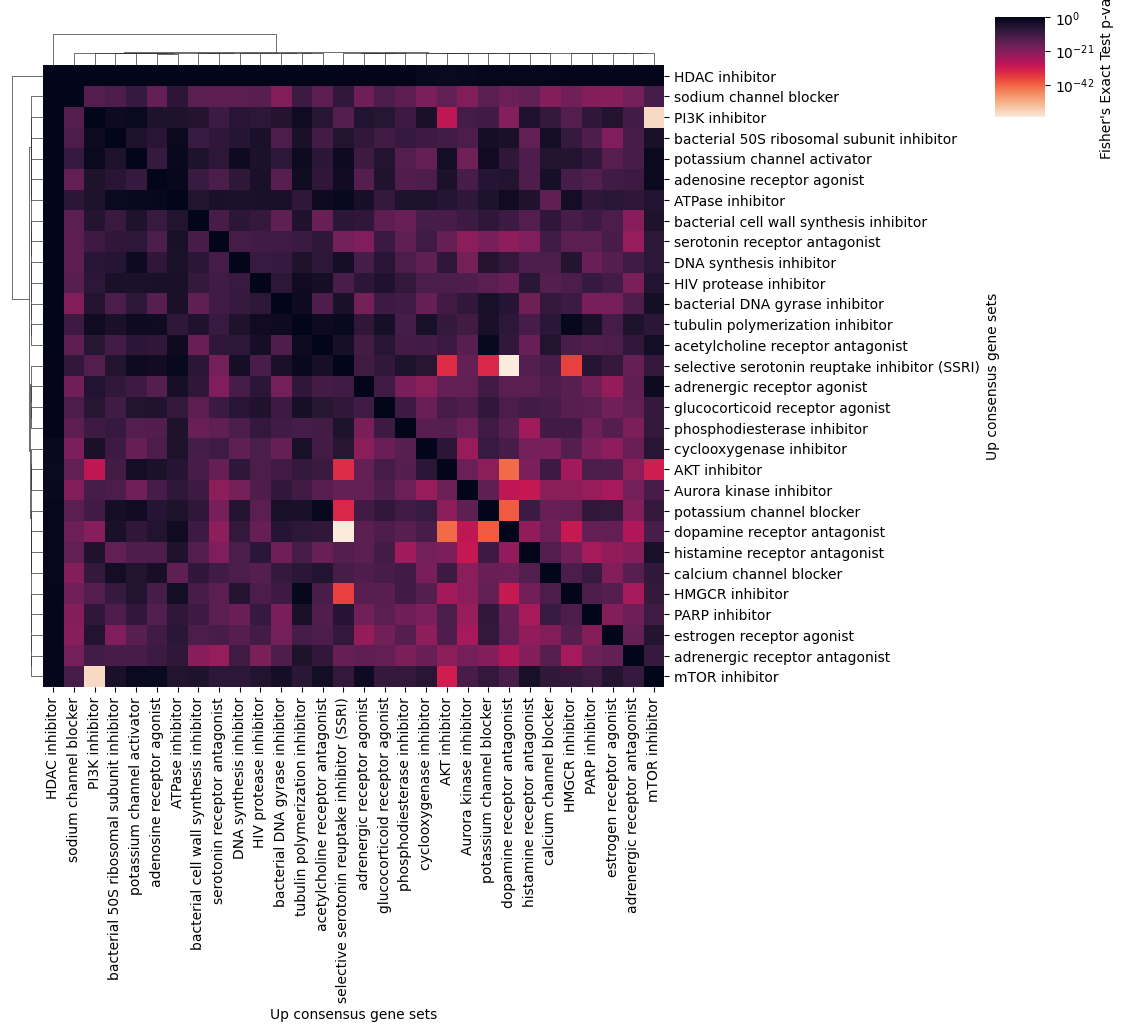

In [200]:
plt.figure(figsize=(10,10))
g = sns.clustermap(up_fishers_mat, annot=False,dendrogram_ratio=(0.05, 0.05), vmax = 0.01, cbar_pos=(1,0.9,0.05,0.1), cmap = 'rocket_r', cbar_kws={'label':"Fisher's Exact Test p-value"}, norm=LogNorm())
g.ax_heatmap.set_xlabel('Up consensus gene sets')
g.ax_heatmap.set_ylabel('Up consensus gene sets')

In [201]:
all_down_genes = set([x for v in DOWN_consensus_moa_gmt.values() for x in v])
down_fishers_mat = pd.DataFrame(index=DOWN_consensus_moa_gmt.keys(), columns=DOWN_consensus_moa_gmt.keys(), data = -1)
for moa_i in down_matrix.index:
    for moa_j in down_matrix.columns:
        genes_i = set(DOWN_consensus_moa_gmt[moa_i])
        genes_j = set(DOWN_consensus_moa_gmt[moa_j])

        A = len(set(genes_i).intersection(set(genes_j)))
        B = len(genes_i) - A
        C = len(genes_j) - A
        D = len(set(all_down_genes) - (genes_i | genes_j))

        res = fisher_exact(np.array([[A, B], [C, D]]), alternative='greater')
        down_fishers_mat.loc[moa_i, moa_j] = res.pvalue

down_fishers_mat.head()

/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/865431062.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.3563741931399857e-138' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  down_fishers_mat.loc[moa_i, moa_j] = res.pvalue
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/865431062.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.2770914533328478e-09' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  down_fishers_mat.loc[moa_i, moa_j] = res.pvalue
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/865431062.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.1153492696866526e-18' has dtype incompatible wit

,dopamine receptor antagonist,glucocorticoid receptor agonist,adrenergic receptor antagonist,cyclooxygenase inhibitor,histamine receptor antagonist,calcium channel blocker,tubulin polymerization inhibitor,phosphodiesterase inhibitor,bacterial cell wall synthesis inhibitor,adrenergic receptor agonist,...,HMGCR inhibitor,bacterial DNA gyrase inhibitor,AKT inhibitor,ATPase inhibitor,DNA synthesis inhibitor,estrogen receptor agonist,potassium channel blocker,Aurora kinase inhibitor,bacterial 50S ribosomal subunit inhibitor,potassium channel activator
dopamine receptor antagonist,1.356374e-138,1.277091e-09,2.115349e-18,9.477096e-08,4.350440e-35,1.408490e-11,2.952220e-12,1.020589e-22,7.923575e-12,9.261842e-12,...,1.630487e-20,8.333175e-12,4.713259e-28,1.309474e-14,4.803316e-10,1.706111e-26,2.086242e-32,3.108333e-29,2.883206e-07,5.310167e-04
glucocorticoid receptor agonist,1.277091e-09,1.121206e-222,6.841805e-15,8.794808e-12,2.050557e-13,9.961178e-08,1.225101e-07,2.392074e-16,5.080477e-04,5.538682e-07,...,1.422727e-14,1.968565e-14,5.526303e-08,2.390016e-07,2.225649e-04,9.356932e-14,5.920339e-10,5.152072e-15,8.984723e-16,5.364966e-04
adrenergic receptor antagonist,2.115349e-18,6.841805e-15,2.440151e-168,7.427064e-17,6.136130e-22,1.123129e-16,3.046859e-12,1.493204e-33,6.854545e-08,7.082310e-14,...,6.691195e-22,7.106453e-22,4.264589e-16,5.366536e-09,7.691151e-11,2.300398e-23,4.182229e-21,9.385479e-30,1.637513e-16,6.359238e-07
cyclooxygenase inhibitor,9.477096e-08,8.794808e-12,7.427064e-17,1.809413e-147,3.965525e-14,4.946473e-09,1.433807e-05,5.259025e-16,1.028523e-05,3.677455e-06,...,1.043517e-07,3.792116e-12,1.890894e-06,2.783804e-04,1.296343e-07,3.346370e-16,7.301410e-06,8.722560e-17,2.376761e-10,1.047075e-07
histamine receptor antagonist,4.350440e-35,2.050557e-13,6.136130e-22,3.965525e-14,2.440151e-168,1.727803e-11,1.069657e-21,1.442012e-24,4.738424e-09,7.082310e-14,...,2.307388e-17,2.328740e-19,4.096596e-22,8.471243e-11,1.739957e-11,6.975550e-29,4.182229e-21,1.186550e-36,1.018135e-13,1.196273e-05


Faux-masking the diagonal by just assigning it max value

In [202]:
for i in down_fishers_mat.columns:
    down_fishers_mat.loc[i,i] = 1

Text(1221.1527777777778, 0.5, 'Down consensus gene sets')

<Figure size 1000x1000 with 0 Axes>

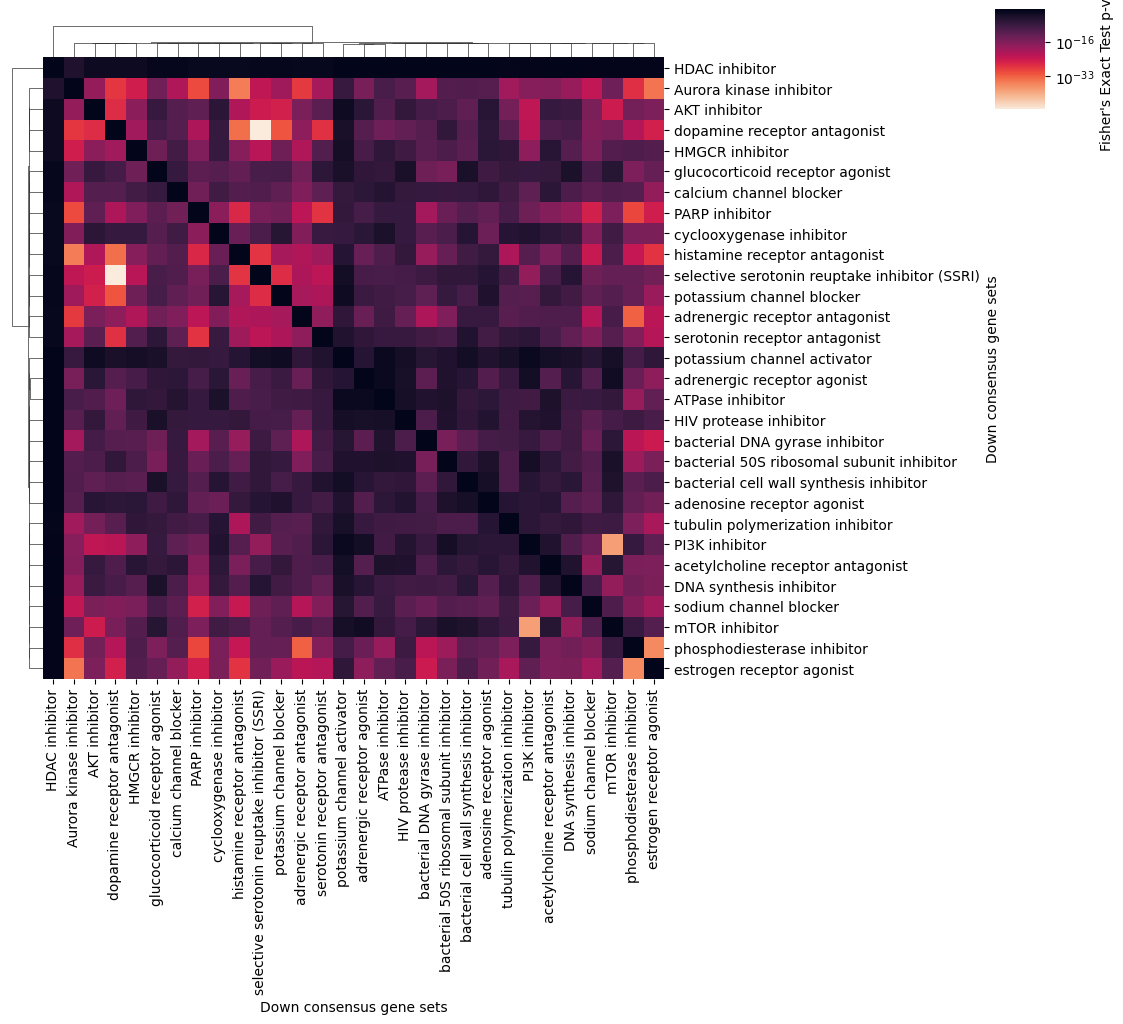

In [203]:
plt.figure(figsize=(10,10))
g = sns.clustermap(down_fishers_mat, annot=False,dendrogram_ratio=(0.05, 0.05), vmax = 0.01, cbar_pos=(1,0.9,0.05,0.1), cmap = 'rocket_r', cbar_kws={'label':"Fisher's Exact Test p-value"}, norm=LogNorm())
g.ax_heatmap.set_xlabel('Down consensus gene sets')
g.ax_heatmap.set_ylabel('Down consensus gene sets')

In [204]:
all_updown_genes = all_down_genes | all_up_genes
updown_fishers_mat = pd.DataFrame(index=UP_consensus_moa_gmt.keys(), columns=DOWN_consensus_moa_gmt.keys(), data = -1)
for moa_up in up_matrix.index:
    for moa_down in down_matrix.columns:
        genes_up = set(UP_consensus_moa_gmt[moa_up])
        genes_down = set(DOWN_consensus_moa_gmt[moa_down])

        A = len(set(genes_up).intersection(set(genes_down)))
        B = len(genes_up) - A
        C = len(genes_down) - A
        D = len(set(all_updown_genes) - (genes_up | genes_down))

        res = fisher_exact(np.array([[A, B], [C, D]]), alternative='greater')
        updown_fishers_mat.loc[moa_up, moa_down] = res.pvalue

updown_fishers_mat.head()

/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/232052745.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.10657777936945e-09' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  updown_fishers_mat.loc[moa_up, moa_down] = res.pvalue
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/232052745.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.5276682511233215e-14' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  updown_fishers_mat.loc[moa_up, moa_down] = res.pvalue
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/232052745.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.647710529922648e-17' has dtype incompat

,dopamine receptor antagonist,glucocorticoid receptor agonist,adrenergic receptor antagonist,cyclooxygenase inhibitor,histamine receptor antagonist,calcium channel blocker,tubulin polymerization inhibitor,phosphodiesterase inhibitor,bacterial cell wall synthesis inhibitor,adrenergic receptor agonist,...,HMGCR inhibitor,bacterial DNA gyrase inhibitor,AKT inhibitor,ATPase inhibitor,DNA synthesis inhibitor,estrogen receptor agonist,potassium channel blocker,Aurora kinase inhibitor,bacterial 50S ribosomal subunit inhibitor,potassium channel activator
dopamine receptor antagonist,5.106578e-09,5.527668e-14,1.647711e-17,4.330740e-30,2.375864e-19,7.111787e-21,3.306723e-17,6.843007e-23,1.468702e-09,8.119287e-08,...,5.671942e-09,6.865318e-20,1.979860e-10,5.099578e-09,4.998760e-22,1.216732e-22,6.294787e-10,7.514801e-25,7.568484e-18,3.332703e-16
glucocorticoid receptor agonist,5.616892e-22,3.225669e-01,2.613105e-21,1.528318e-10,2.730335e-23,4.423163e-18,3.355759e-16,3.269390e-18,9.141754e-11,1.677101e-11,...,1.524934e-14,4.096027e-13,4.728791e-13,2.282944e-06,6.099600e-14,1.106824e-21,2.604926e-16,5.584231e-24,2.162034e-08,2.611976e-08
adrenergic receptor antagonist,4.329104e-23,6.017691e-13,8.577614e-24,7.394852e-29,1.006668e-29,4.399907e-15,1.756446e-19,6.120106e-24,1.148552e-08,1.650006e-14,...,3.483927e-08,9.080600e-15,1.612596e-12,2.380921e-09,1.857150e-13,1.106699e-32,3.157538e-13,3.980504e-30,8.892160e-17,3.629834e-14
cyclooxygenase inhibitor,6.252047e-39,6.798496e-13,7.744589e-26,2.511348e-08,3.665020e-32,7.581964e-27,3.961388e-28,2.696897e-27,3.292403e-17,1.064964e-12,...,6.464947e-24,1.334548e-18,2.940584e-31,7.510444e-20,6.736133e-17,2.084687e-27,8.946622e-26,7.432159e-40,6.505229e-16,1.089014e-10
histamine receptor antagonist,2.944689e-23,8.956733e-17,2.213911e-25,4.025416e-26,3.879741e-20,2.456276e-20,1.446797e-15,3.610056e-25,2.859365e-10,1.280395e-11,...,8.189988e-14,4.666407e-19,1.292069e-17,1.733030e-15,1.803667e-15,2.134610e-30,1.067954e-16,5.315267e-33,1.597105e-14,2.951638e-10


Text(1221.1527777777778, 0.5, 'Down consensus gene sets')

<Figure size 1000x1000 with 0 Axes>

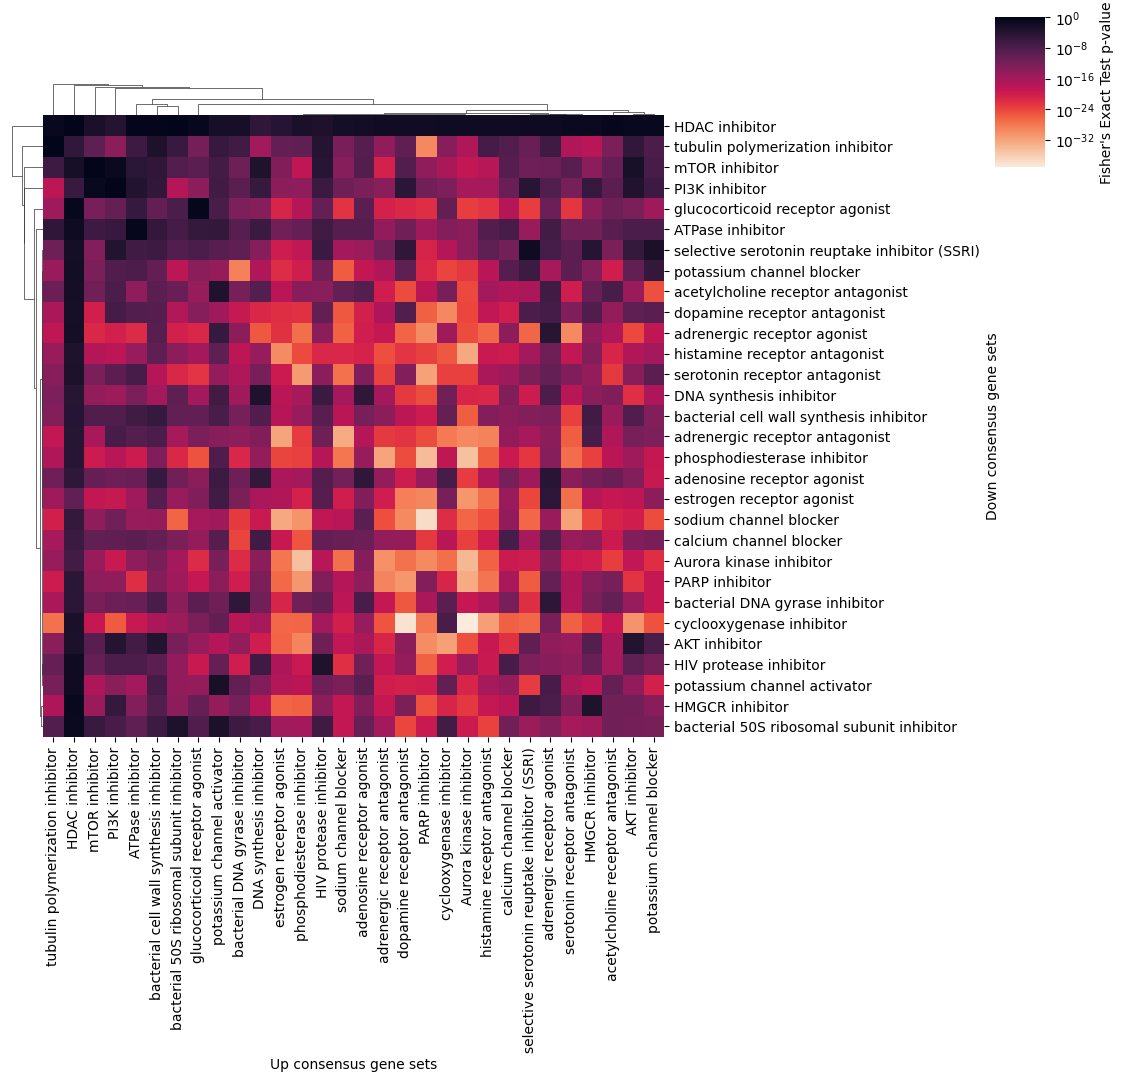

In [205]:
plt.figure(figsize=(10,10))
g = sns.clustermap(updown_fishers_mat, annot=False,dendrogram_ratio=(0.05, 0.05), cbar_pos=(1,0.9,0.05,0.15), cmap = 'rocket_r', cbar_kws={'label':"Fisher's Exact Test p-value"}, norm=LogNorm())
g.ax_heatmap.set_xlabel('Up consensus gene sets')
g.ax_heatmap.set_ylabel('Down consensus gene sets')

# UMAP

In [206]:
# Scatterplot
import urllib.request
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import scanpy as sc
import anndata
import pyarrow.feather as feather
from collections import OrderedDict
# Annealing
import pickle
import math
import time
from random import randint
from os import path, mkdir
# Bokeh
from bokeh.io import output_notebook
from bokeh.plotting import figure, show, save, output_file
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.palettes import Category20
output_notebook()

from IPython.display import display, HTML, Markdown

Loading BokehJS ...

In [302]:
up_libname = 'up_consensus_top_30_moa'
dn_libname = 'down_consensus_top_30_moa'
both_libname = 'consensus_top_30_moa'
libdir = './data/out'

In [303]:
def get_scatter_library(libname, local):
    '''
    Processes the GMT file for the input Enrichr library {lib} and returns a 
    dictionary where the keys correspond to gene set names, and the value for
    each key is a space-delimited string containing all genes belonging to
    the gene set: 
    {
        "gene set name": "gene_1 gene_2 gene_3 ... gene_n", 
        ...
    }
    In addition, this function can augment each gene set library using ARCHS4 
    gene-gene co-expression data. For each gene set, the most co-expressed genes 
    (determined by summing the coexpression coefficients across all genes)
    are added to the gene set before visualization. 
    '''
    ### open local file or from Enrichr
    if local: 
        print(f"\tOpening library locally from '{libdir}'...")
        with open(f"{libdir}/{libname}.gmt", 'r') as f:
            lines = f.readlines()
    else: 
        print(f"\tOpening library from Enrichr database...")
        with urllib.request.urlopen(f'https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName={libname}') as f:
            lines = [l.decode('utf-8') for l in f.readlines()]

    ### variables to store gene set data
    lib_dict = OrderedDict()


    print("\tProcessing gene sets without augmentation...")

    for line in lines:
        tokens = line.split("\t\t")
        term = tokens[0]
        genes = [x.split(',')[0].strip() for x in tokens[1].split('\t')]

        lib_dict[term] = ' '.join(genes)
    
    return lib_dict

In [317]:
def process_scatterplot(libdict, nneighbors=30, mindist=0.1, spread=1.0, maxdf=1.0, mindf=1, color_by='cluster'):
    print("\tTF-IDF vectorizing gene set data...")
    vec = TfidfVectorizer(max_df=maxdf, min_df=mindf)
    X = vec.fit_transform(libdict.values())
    print(X.shape)
    adata = anndata.AnnData(X)
    adata.obs.index = libdict.keys()

    print("\tPerforming Leiden clustering...")
    ### the n_neighbors and min_dist parameters can be altered
    sc.pp.neighbors(adata, n_neighbors=nneighbors, n_pcs=29)
    sc.tl.leiden(adata, resolution=1.0)
    sc.tl.umap(adata, min_dist=mindist, spread=spread, random_state=42)

    new_order = adata.obs.sort_values(by='leiden').index.tolist()
    adata = adata[new_order, :]
    adata.obs['leiden'] = 'Cluster ' + adata.obs['leiden'].astype('object')

    df = pd.DataFrame(adata.obsm['X_umap'])
    df.columns = ['x', 'y']

    if color_by=='cluster':
        df['cluster'] = adata.obs['leiden'].values
    else:
        df['cluster'] = adata.obs.index.map(lambda x: x.split(" ")[-1])
    df['term'] = adata.obs.index
    df['genes'] = [libdict[l] for l in df['term']]

    return df

In [318]:
def get_scatter_colors(df):
    clusters = pd.unique(df['cluster']).tolist()
    colors = list(Category20[20])[::2] + list(Category20[20])[1::2]
    color_mapper = {clusters[i]: colors[i % 20] for i in range(len(clusters))}
    return color_mapper

def get_scatterplot(scatterdf):
    df = scatterdf.copy()
    color_mapper = get_scatter_colors(df)
    df['color'] = df['cluster'].apply(lambda x: color_mapper[x])

    tooltips = [
        ("Gene Set", "@gene_set"),
        ("Cluster", "@label")
    ]
        
    hover_emb = HoverTool(tooltips=tooltips)
    tools_emb = [hover_emb, 'pan', 'wheel_zoom', 'reset', 'save']

    plot_emb = figure(
        width=600, 
        height=600, 
        tools=tools_emb
    )

    source = ColumnDataSource(
        data=dict(
            x = df['x'],
            y = df['y'],
            gene_set = df['term'],
            colors = df['color'],
            label = df['cluster']
        )
    )

    # hide axis labels and grid lines
    plot_emb.xaxis.major_tick_line_color = None
    plot_emb.xaxis.minor_tick_line_color = None
    plot_emb.yaxis.major_tick_line_color = None
    plot_emb.yaxis.minor_tick_line_color = None
    plot_emb.xaxis.major_label_text_font_size = '0pt'
    plot_emb.yaxis.major_label_text_font_size = '0pt' 

    plot_emb.output_backend = "svg"    
    
    plot_emb.xaxis.axis_label = "UMAP_1"
    plot_emb.yaxis.axis_label = "UMAP_2"
    plot_emb.legend.padding = 1
    
    s = plot_emb.scatter(
        'x', 
        'y', 
        size = 10, 
        source = source, 
        color = 'colors', 
        #legend_group = 'label'
    )

    #plot_emb.add_layout(plot_emb.legend[0], 'right')
    
    return plot_emb

In [319]:
l_dict_up = get_scatter_library(up_libname, local=True)
l_dict_dn = get_scatter_library(dn_libname, local=True)
l_dict_both = get_scatter_library(both_libname, local=True)

	Opening library locally from './data/out'...
	Processing gene sets without augmentation...
	Opening library locally from './data/out'...
	Processing gene sets without augmentation...
	Opening library locally from './data/out'...
	Processing gene sets without augmentation...


In [320]:
print(f"Now processing {up_libname}")
## defaults: nneighbors=30, mindist=0.1, spread=1.0, maxdf=1.0, mindf=1
scatter_df = process_scatterplot(
    l_dict_up, 
    nneighbors=7,
    mindist=0.01,
    # spread=0.8, 
    # maxdf=0.5, 
    # mindf=10
)
print(f"\tDone!")

plot = get_scatterplot(scatter_df)
display(HTML(f"<div style='font-size:1.5rem;'>Scatter plot visualization for {up_libname}.</div>"))
show(plot)

Now processing up_consensus_top_30_moa
	TF-IDF vectorizing gene set data...
(30, 1421)
	Performing Leiden clustering...
	Done!


/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:11: UserWarning: You’re trying to run this on 1421 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(adata, n_neighbors=nneighbors, n_pcs=29)
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:12: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.0)
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of vi

In [336]:
print(f"Now processing {dn_libname}")
## defaults: nneighbors=30, mindist=0.1, spread=1.0, maxdf=1.0, mindf=1
scatter_df = process_scatterplot(
    l_dict_dn, 
    nneighbors=3,
    mindist=0.01,
    # spread=0.8, 
    # maxdf=0.5, 
    # mindf=10
)
print(f"\tDone!")

plot = get_scatterplot(scatter_df)
display(HTML(f"<div style='font-size:1.5rem;'>Scatter plot visualization for {dn_libname}.</div>"))
show(plot)

Now processing down_consensus_top_30_moa
	TF-IDF vectorizing gene set data...
(30, 1279)
	Performing Leiden clustering...
	Done!


/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:11: UserWarning: You’re trying to run this on 1279 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(adata, n_neighbors=nneighbors, n_pcs=29)
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:12: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.0)
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of vi

In [337]:
print(f"Now processing {both_libname}")
## defaults: nneighbors=30, mindist=0.1, spread=1.0, maxdf=1.0, mindf=1
scatter_df = process_scatterplot(
    l_dict_both, 
    nneighbors=4,
    mindist=0.05,
    # spread=0.8, 
    # maxdf=0.5, 
    # mindf=10
)
print(f"\tDone!")

plot = get_scatterplot(scatter_df)
display(HTML(f"<div style='font-size:1.5rem;'>Scatter plot visualization for {both_libname}.</div>"))
show(plot)

Now processing consensus_top_30_moa
	TF-IDF vectorizing gene set data...
(60, 1807)
	Performing Leiden clustering...
	Done!


/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:11: UserWarning: You’re trying to run this on 1807 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(adata, n_neighbors=nneighbors, n_pcs=29)
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:12: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.0)
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of vi

In [335]:
print(f"Now processing {both_libname}")
## defaults: nneighbors=30, mindist=0.1, spread=1.0, maxdf=1.0, mindf=1
scatter_df = process_scatterplot(
    l_dict_both, 
    nneighbors=4,
    mindist=0.05,
    color_by="direction"
    # spread=0.8, 
    # maxdf=0.5, 
    # mindf=10
)
print(f"\tDone!")

plot = get_scatterplot(scatter_df)
display(HTML(f"<div style='font-size:1.5rem;'>Scatter plot visualization for {both_libname}.</div>"))
show(plot)

Now processing consensus_top_30_moa
	TF-IDF vectorizing gene set data...
(60, 1807)
	Performing Leiden clustering...
	Done!


/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:11: UserWarning: You’re trying to run this on 1807 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(adata, n_neighbors=nneighbors, n_pcs=29)
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:12: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.0)
/var/folders/8r/rnwphsss465cd53qqc8bmn_40000gn/T/ipykernel_633/2410697657.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of vi